# Cross-Validation Techniques

Cross-validation is a statistical method for evaluating and comparing learning algorithms by dividing data into two segments: one used to train the model and the other to validate it. This notebook explores three fundamental cross-validation techniques and when to use each.

## Setup and Imports

We'll use scikit-learn's cross-validation tools along with our shared utilities for data handling.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, StratifiedKFold, TimeSeriesSplit
from sklearn.datasets import make_classification, make_regression
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import accuracy_score, mean_squared_error
from aiml_notebooks import set_seed

set_seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## The Problem: Single Train/Test Split

Before diving into cross-validation, let's understand why a single train/test split can be problematic. The performance estimate depends heavily on which samples end up in the test set.

In [2]:
# Generate a simple dataset
X, y = make_classification(n_samples=100, n_features=20, n_informative=15, 
                          n_redundant=5, random_state=42)

print(f"Dataset shape: {X.shape}")
print(f"Class distribution: {np.bincount(y)}")

Dataset shape: (100, 20)
Class distribution: [50 50]


Let's perform multiple random train/test splits and observe the variance in performance.

In [3]:
from sklearn.model_selection import train_test_split

# Perform 20 different random splits
accuracies = []
for i in range(20):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=i
    )
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

accuracies = np.array(accuracies)
print(f"Mean accuracy: {accuracies.mean():.3f} ± {accuracies.std():.3f}")
print(f"Min: {accuracies.min():.3f}, Max: {accuracies.max():.3f}")
print(f"Range: {accuracies.max() - accuracies.min():.3f}")

Mean accuracy: 0.710 ± 0.096
Min: 0.450, Max: 0.850
Range: 0.400


Visualize the variance across different random splits.

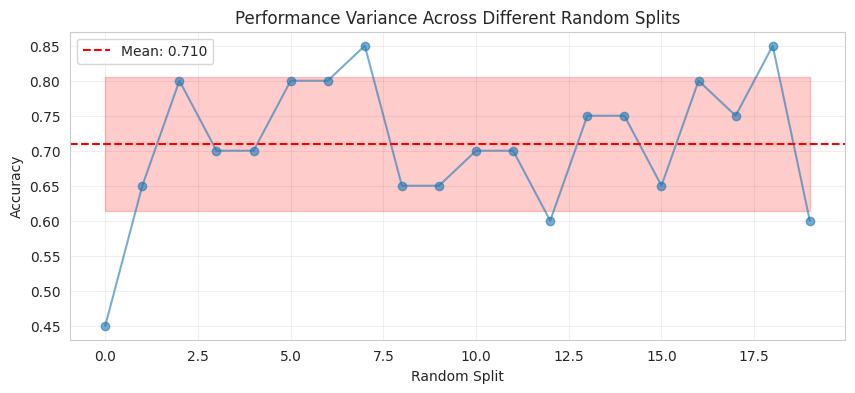

In [4]:
plt.figure(figsize=(10, 4))
plt.plot(accuracies, 'o-', alpha=0.6)
plt.axhline(accuracies.mean(), color='red', linestyle='--', label=f'Mean: {accuracies.mean():.3f}')
plt.fill_between(range(len(accuracies)), 
                 accuracies.mean() - accuracies.std(),
                 accuracies.mean() + accuracies.std(),
                 alpha=0.2, color='red')
plt.xlabel('Random Split')
plt.ylabel('Accuracy')
plt.title('Performance Variance Across Different Random Splits')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Key Insight**: A single split gives us only one performance estimate, which may not be representative. Cross-validation addresses this by using multiple splits systematically.

## K-Fold Cross-Validation

K-fold CV divides the dataset into K equal-sized folds. The model is trained K times, each time using K-1 folds for training and the remaining fold for validation. This ensures every sample is used for validation exactly once.

### Visualizing K-Fold Splits

Let's visualize how K-fold divides the data with K=5.

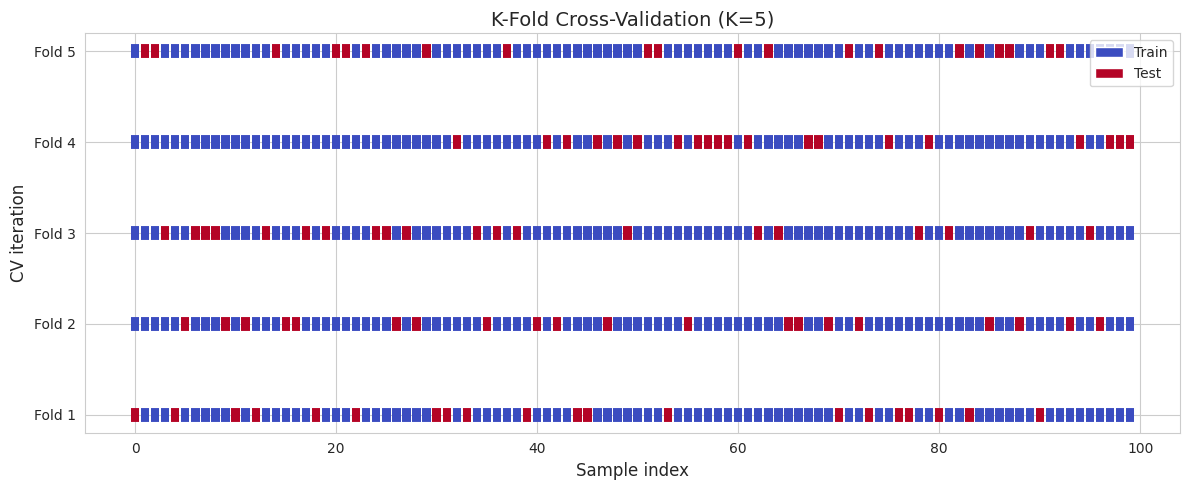

In [5]:
def plot_cv_indices(cv, X, y, n_splits, ax, title):
    """Visualize cross-validation indices."""
    cmap_cv = plt.cm.coolwarm
    
    for i, (train_idx, test_idx) in enumerate(cv.split(X, y)):
        # Visualize the training and test sets
        indices = np.zeros(len(X))
        indices[test_idx] = 1
        
        ax.scatter(range(len(indices)), [i] * len(indices),
                  c=indices, marker='_', lw=10, cmap=cmap_cv,
                  vmin=0, vmax=1)
    
    ax.set_xlabel('Sample index', fontsize=12)
    ax.set_ylabel('CV iteration', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.set_yticks(range(n_splits))
    ax.set_yticklabels([f'Fold {i+1}' for i in range(n_splits)])
    
    # Add colorbar
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=cmap_cv(0.), label='Train'),
                      Patch(facecolor=cmap_cv(1.), label='Test')]
    ax.legend(handles=legend_elements, loc='upper right')

# Create visualization
fig, ax = plt.subplots(figsize=(12, 5))
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
plot_cv_indices(kfold, X, y, 5, ax, 'K-Fold Cross-Validation (K=5)')
plt.tight_layout()
plt.show()

**Observation**: Each fold (row) uses a different portion of the data for testing (red). Every sample appears in exactly one test set.

### Implementing K-Fold Cross-Validation

Let's manually implement K-fold to understand the process, then use scikit-learn's built-in function.

In [6]:
# Manual implementation
n_splits = 5
kfold = KFold(n_splits=n_splits, shuffle=True, random_state=42)

fold_scores = []
for fold, (train_idx, val_idx) in enumerate(kfold.split(X), 1):
    # Split data
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    
    # Train and evaluate
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    score = accuracy_score(y_val, y_pred)
    fold_scores.append(score)
    
    print(f"Fold {fold}: Train size={len(train_idx)}, Val size={len(val_idx)}, Accuracy={score:.3f}")

fold_scores = np.array(fold_scores)
print(f"\nMean CV accuracy: {fold_scores.mean():.3f} ± {fold_scores.std():.3f}")

Fold 1: Train size=80, Val size=20, Accuracy=0.700
Fold 2: Train size=80, Val size=20, Accuracy=0.600


Fold 3: Train size=80, Val size=20, Accuracy=0.700
Fold 4: Train size=80, Val size=20, Accuracy=0.700


Fold 5: Train size=80, Val size=20, Accuracy=0.900

Mean CV accuracy: 0.720 ± 0.098


Now use scikit-learn's `cross_val_score` for convenience.

In [7]:
from sklearn.model_selection import cross_val_score

model = LogisticRegression(max_iter=1000)
scores = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')

print(f"Cross-validation scores: {scores}")
print(f"Mean: {scores.mean():.3f} ± {scores.std():.3f}")

Cross-validation scores: [0.7 0.6 0.7 0.7 0.9]
Mean: 0.720 ± 0.098


### Comparing K-Fold vs Single Split

Let's compare the stability of K-fold CV versus a single split.

In [8]:
# Repeat K-fold CV multiple times with different random states
kfold_means = []
for random_state in range(20):
    kf = KFold(n_splits=5, shuffle=True, random_state=random_state)
    scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')
    kfold_means.append(scores.mean())

kfold_means = np.array(kfold_means)
print(f"K-Fold means: {kfold_means.mean():.3f} ± {kfold_means.std():.3f}")
print(f"Single split: {accuracies.mean():.3f} ± {accuracies.std():.3f}")
print(f"\nVariance reduction: {(accuracies.std() - kfold_means.std()) / accuracies.std() * 100:.1f}%")

K-Fold means: 0.736 ± 0.030
Single split: 0.710 ± 0.096

Variance reduction: 68.6%


Visualize the comparison.

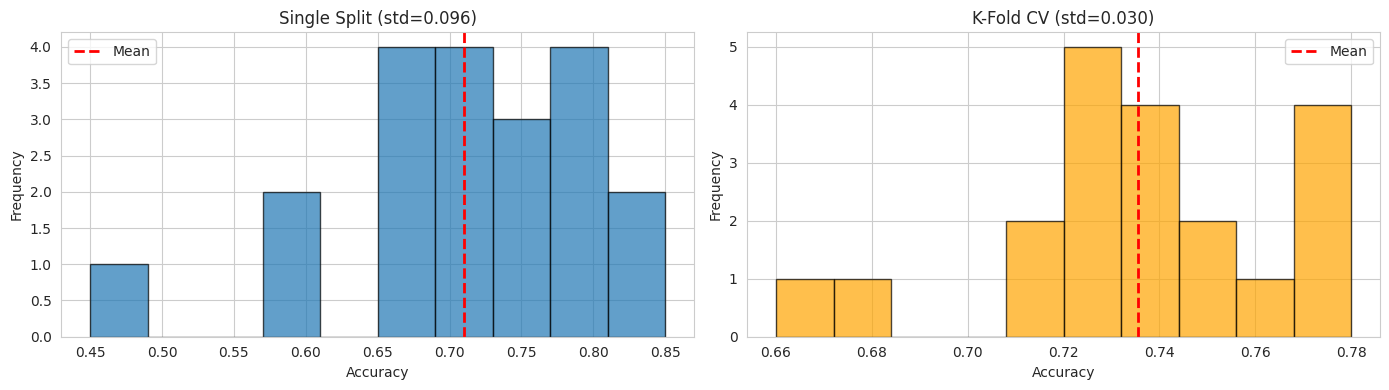

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Single split
axes[0].hist(accuracies, bins=10, alpha=0.7, edgecolor='black')
axes[0].axvline(accuracies.mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0].set_xlabel('Accuracy')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Single Split (std={accuracies.std():.3f})')
axes[0].legend()

# K-fold
axes[1].hist(kfold_means, bins=10, alpha=0.7, edgecolor='black', color='orange')
axes[1].axvline(kfold_means.mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[1].set_xlabel('Accuracy')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'K-Fold CV (std={kfold_means.std():.3f})')
axes[1].legend()

plt.tight_layout()
plt.show()

**Key Insight**: K-fold cross-validation produces more stable estimates with lower variance.

### Effect of K

How does the choice of K affect our results? Let's experiment with different values.

In [10]:
k_values = [2, 3, 5, 10, 20]
k_results = []

for k in k_values:
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')
    k_results.append({
        'k': k,
        'mean': scores.mean(),
        'std': scores.std(),
        'scores': scores
    })
    print(f"K={k:2d}: {scores.mean():.3f} ± {scores.std():.3f}")

K= 2: 0.760 ± 0.060
K= 3: 0.770 ± 0.062


K= 5: 0.720 ± 0.098
K=10: 0.760 ± 0.174


K=20: 0.760 ± 0.196


Visualize the trade-off between K and variance.

/tmp/ipykernel_120181/3379894682.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([r['scores'] for r in k_results], labels=k_values)


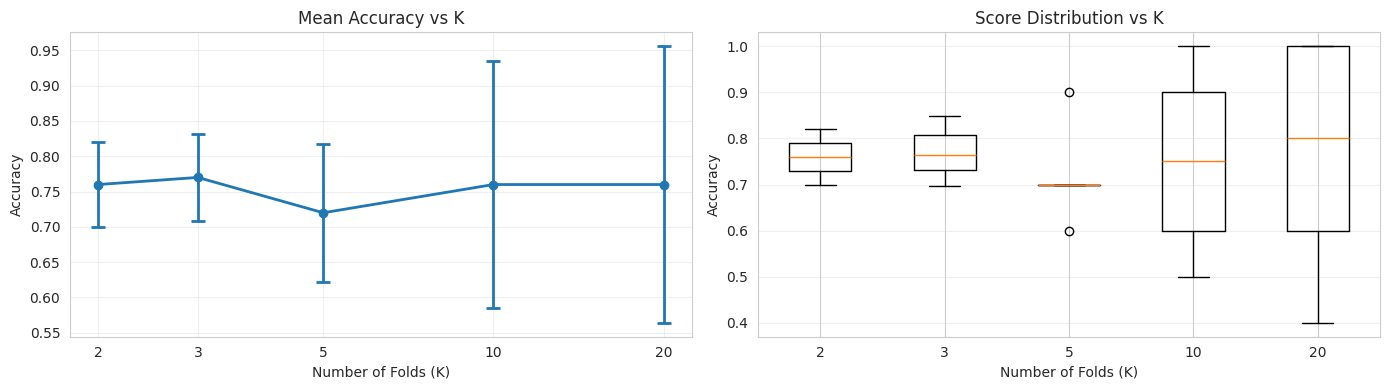

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Plot mean and std
means = [r['mean'] for r in k_results]
stds = [r['std'] for r in k_results]

ax1.errorbar(k_values, means, yerr=stds, marker='o', capsize=5, capthick=2, linewidth=2)
ax1.set_xlabel('Number of Folds (K)')
ax1.set_ylabel('Accuracy')
ax1.set_title('Mean Accuracy vs K')
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log')
ax1.set_xticks(k_values)
ax1.get_xaxis().set_major_formatter(plt.ScalarFormatter())

# Box plot
ax2.boxplot([r['scores'] for r in k_results], labels=k_values)
ax2.set_xlabel('Number of Folds (K)')
ax2.set_ylabel('Accuracy')
ax2.set_title('Score Distribution vs K')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

**Trade-off**: Larger K means more training data per fold (less bias) but more variance between folds. K=5 or K=10 are common choices.

## Stratified K-Fold Cross-Validation

Regular K-fold randomly assigns samples to folds, which can lead to imbalanced class distributions. Stratified K-fold preserves the percentage of samples for each class in each fold.

### When is Stratification Important?

Let's create an imbalanced dataset to demonstrate the problem.

In [12]:
# Create imbalanced dataset: 80% class 0, 20% class 1
X_imb, y_imb = make_classification(
    n_samples=200, n_features=20, n_informative=15,
    n_redundant=5, weights=[0.8, 0.2], flip_y=0.01, random_state=42
)

print(f"Total samples: {len(y_imb)}")
print(f"Class distribution: {np.bincount(y_imb)}")
print(f"Class proportions: {np.bincount(y_imb) / len(y_imb)}")

Total samples: 200
Class distribution: [159  41]
Class proportions: [0.795 0.205]


Compare class distributions in folds between regular K-fold and stratified K-fold.

In [13]:
def analyze_fold_distributions(cv, X, y, name):
    """Analyze class distributions across folds."""
    print(f"\n{name}:")
    print("=" * 60)
    fold_props = []
    
    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), 1):
        val_counts = np.bincount(y[val_idx])
        val_props = val_counts / len(val_idx)
        fold_props.append(val_props[1])  # Track proportion of class 1
        
        print(f"Fold {fold}: Val class distribution: {val_counts} "
              f"(proportions: {val_props[0]:.3f}, {val_props[1]:.3f})")
    
    fold_props = np.array(fold_props)
    print(f"\nClass 1 proportion across folds: {fold_props.mean():.3f} ± {fold_props.std():.3f}")
    return fold_props

# Regular K-fold
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
kfold_props = analyze_fold_distributions(kfold, X_imb, y_imb, "Regular K-Fold")

# Stratified K-fold
skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skfold_props = analyze_fold_distributions(skfold, X_imb, y_imb, "Stratified K-Fold")


Regular K-Fold:
Fold 1: Val class distribution: [31  9] (proportions: 0.775, 0.225)
Fold 2: Val class distribution: [30 10] (proportions: 0.750, 0.250)
Fold 3: Val class distribution: [33  7] (proportions: 0.825, 0.175)
Fold 4: Val class distribution: [31  9] (proportions: 0.775, 0.225)
Fold 5: Val class distribution: [34  6] (proportions: 0.850, 0.150)

Class 1 proportion across folds: 0.205 ± 0.037

Stratified K-Fold:
Fold 1: Val class distribution: [32  8] (proportions: 0.800, 0.200)
Fold 2: Val class distribution: [32  8] (proportions: 0.800, 0.200)
Fold 3: Val class distribution: [32  8] (proportions: 0.800, 0.200)
Fold 4: Val class distribution: [32  8] (proportions: 0.800, 0.200)
Fold 5: Val class distribution: [31  9] (proportions: 0.775, 0.225)

Class 1 proportion across folds: 0.205 ± 0.010


Visualize the difference in class distribution stability.

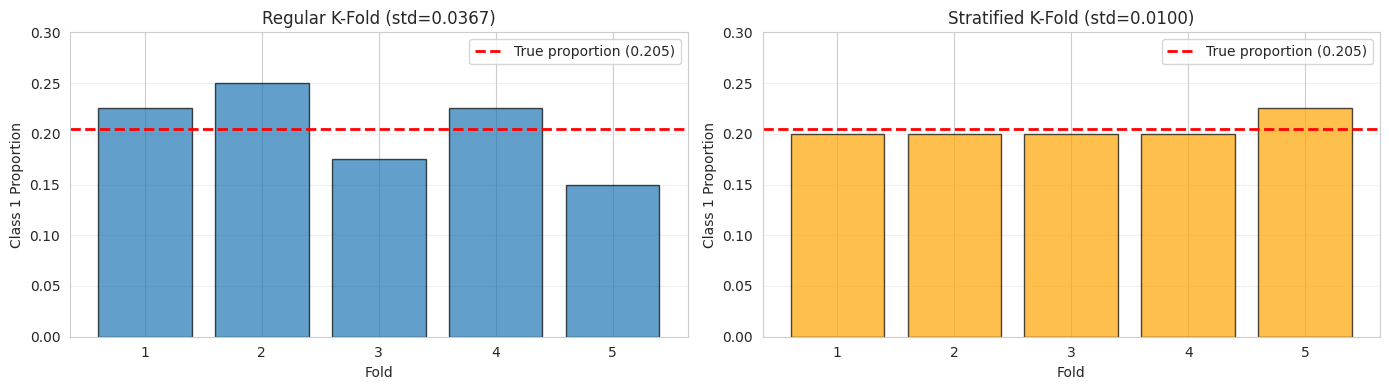

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# True proportion line
true_prop = np.bincount(y_imb)[1] / len(y_imb)

# Regular K-fold
ax1.bar(range(1, 6), kfold_props, alpha=0.7, edgecolor='black')
ax1.axhline(true_prop, color='red', linestyle='--', linewidth=2, label=f'True proportion ({true_prop:.3f})')
ax1.set_xlabel('Fold')
ax1.set_ylabel('Class 1 Proportion')
ax1.set_title(f'Regular K-Fold (std={kfold_props.std():.4f})')
ax1.set_ylim([0, max(kfold_props.max(), skfold_props.max()) * 1.2])
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Stratified K-fold
ax2.bar(range(1, 6), skfold_props, alpha=0.7, edgecolor='black', color='orange')
ax2.axhline(true_prop, color='red', linestyle='--', linewidth=2, label=f'True proportion ({true_prop:.3f})')
ax2.set_xlabel('Fold')
ax2.set_ylabel('Class 1 Proportion')
ax2.set_title(f'Stratified K-Fold (std={skfold_props.std():.4f})')
ax2.set_ylim([0, max(kfold_props.max(), skfold_props.max()) * 1.2])
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

**Key Insight**: Stratified K-fold maintains consistent class proportions across folds, crucial for imbalanced datasets.

### Performance Impact

Does stratification improve model evaluation stability?

In [15]:
model = LogisticRegression(max_iter=1000)

# Regular K-fold
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
kfold_scores = cross_val_score(model, X_imb, y_imb, cv=kfold, scoring='accuracy')

# Stratified K-fold
skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skfold_scores = cross_val_score(model, X_imb, y_imb, cv=skfold, scoring='accuracy')

print(f"Regular K-Fold:     {kfold_scores.mean():.3f} ± {kfold_scores.std():.3f}")
print(f"Stratified K-Fold:  {skfold_scores.mean():.3f} ± {skfold_scores.std():.3f}")
print(f"\nVariance reduction: {(kfold_scores.std() - skfold_scores.std()) / kfold_scores.std() * 100:.1f}%")

Regular K-Fold:     0.880 ± 0.029
Stratified K-Fold:  0.885 ± 0.030

Variance reduction: -2.9%


Visualize the score distributions.

/tmp/ipykernel_120181/317497617.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([kfold_scores, skfold_scores],


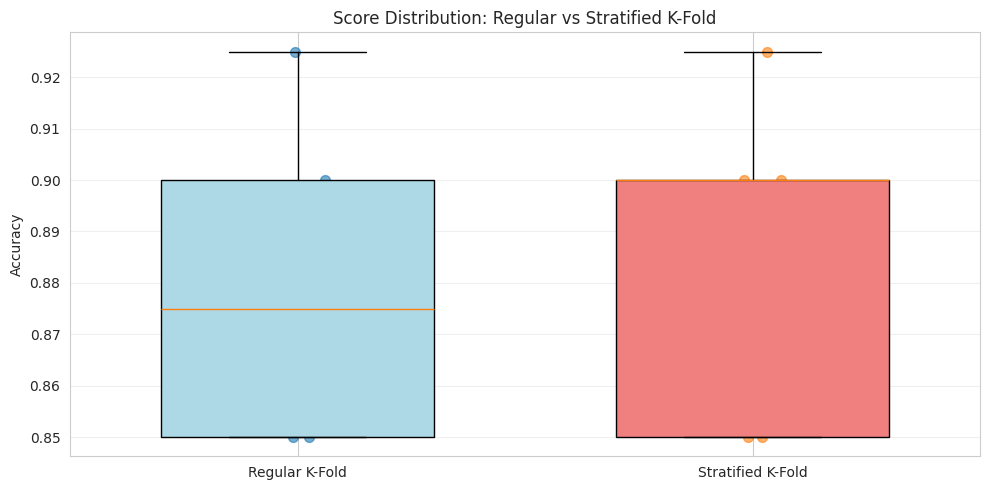

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

positions = [1, 2]
bp = ax.boxplot([kfold_scores, skfold_scores], 
                 positions=positions,
                 labels=['Regular K-Fold', 'Stratified K-Fold'],
                 patch_artist=True,
                 widths=0.6)

# Color boxes
colors = ['lightblue', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_ylabel('Accuracy')
ax.set_title('Score Distribution: Regular vs Stratified K-Fold')
ax.grid(True, alpha=0.3, axis='y')

# Add scatter of actual values
for i, scores in enumerate([kfold_scores, skfold_scores], 1):
    x = np.random.normal(i, 0.04, len(scores))
    ax.scatter(x, scores, alpha=0.6, s=50)

plt.tight_layout()
plt.show()

**Recommendation**: Always use stratified K-fold for classification tasks, especially with imbalanced datasets.

## Time Series Cross-Validation

Time series data has temporal ordering that must be preserved. We cannot randomly shuffle samples because future data should never be used to predict the past. Time series split uses a "forward chaining" approach.

### Why Regular K-Fold Fails for Time Series

Using future data to predict the past leads to data leakage and overly optimistic performance estimates.

In [17]:
# Create synthetic time series data
n_samples = 200
time = np.arange(n_samples)

# Trend + seasonality + noise
trend = 0.5 * time
seasonality = 10 * np.sin(2 * np.pi * time / 50)
noise = np.random.randn(n_samples) * 5
y_ts = trend + seasonality + noise

# Features: time and lagged values
X_ts = np.column_stack([
    time,
    np.roll(y_ts, 1),  # lag 1
    np.roll(y_ts, 2),  # lag 2
])
# Remove first 2 samples (invalid lags)
X_ts = X_ts[2:]
y_ts = y_ts[2:]
time = time[2:]

print(f"Time series shape: {X_ts.shape}")
print(f"Time range: {time[0]} to {time[-1]}")

Time series shape: (198, 3)
Time range: 2 to 199


Visualize the time series.

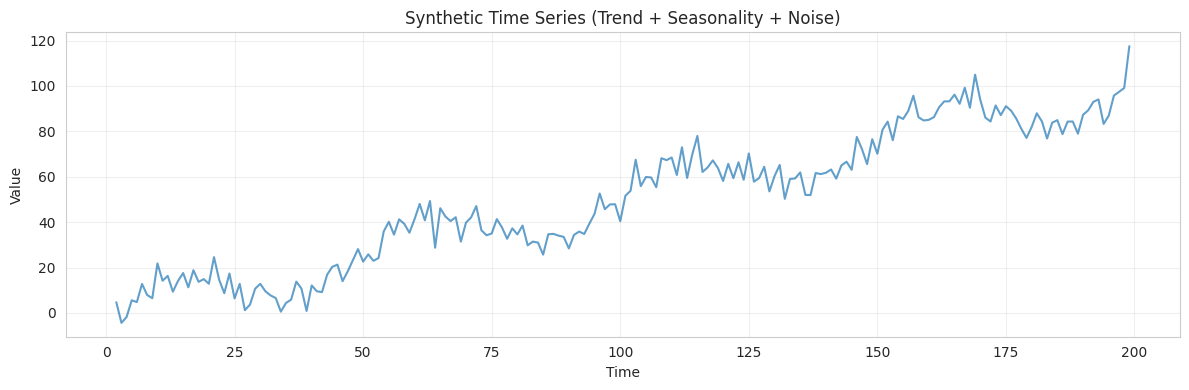

In [18]:
plt.figure(figsize=(12, 4))
plt.plot(time, y_ts, alpha=0.7)
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Synthetic Time Series (Trend + Seasonality + Noise)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Visualizing Time Series Split

Time series split uses an expanding window: each fold includes all previous data for training.

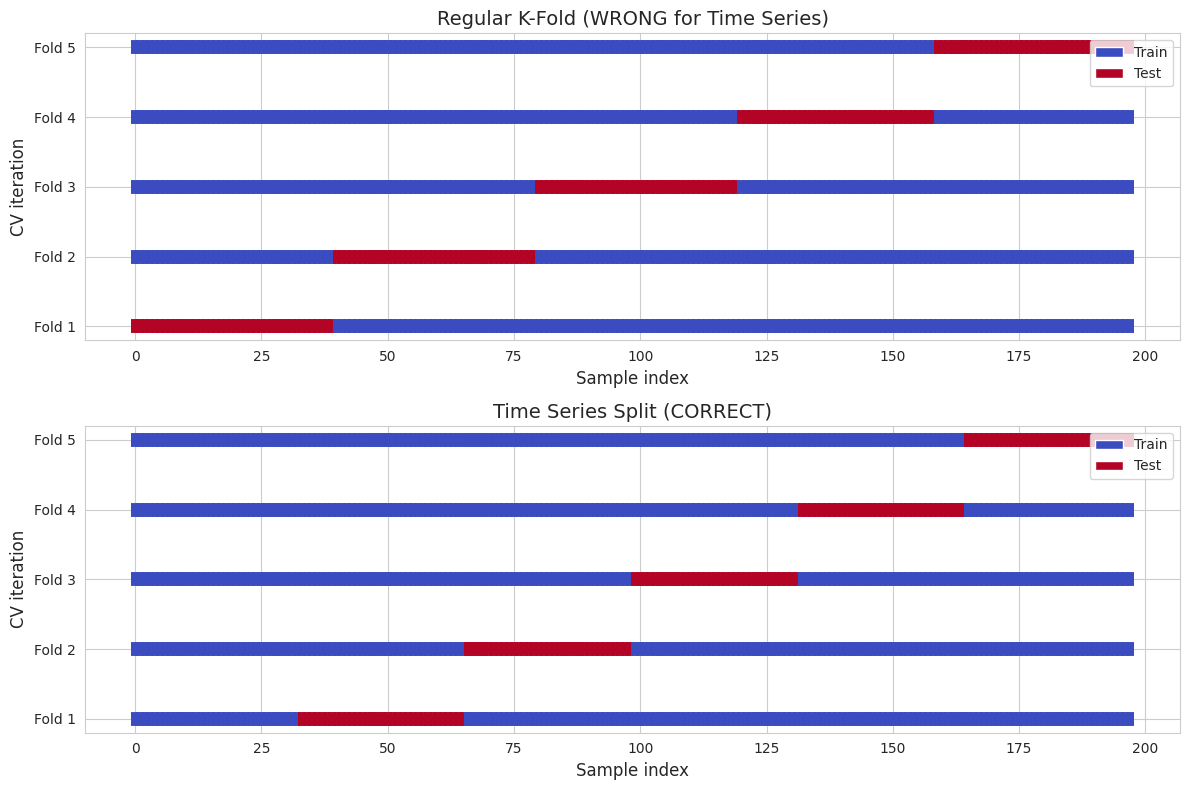

In [19]:
# Visualize time series split
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Regular K-fold (WRONG for time series)
kfold = KFold(n_splits=5, shuffle=False)
plot_cv_indices(kfold, X_ts, y_ts, 5, ax1, 'Regular K-Fold (WRONG for Time Series)')

# Time series split (CORRECT)
tscv = TimeSeriesSplit(n_splits=5)
plot_cv_indices(tscv, X_ts, y_ts, 5, ax2, 'Time Series Split (CORRECT)')

plt.tight_layout()
plt.show()

**Key Observation**: Time series split respects temporal order - training always comes before testing, and each fold includes more historical data.

### Demonstrating Data Leakage

Let's show how using future data leads to overly optimistic estimates.

In [20]:
model = Ridge(alpha=1.0)

# Regular K-fold (with data leakage)
kfold = KFold(n_splits=5, shuffle=False)
kfold_scores = cross_val_score(model, X_ts, y_ts, cv=kfold, 
                                scoring='neg_mean_squared_error')
kfold_rmse = np.sqrt(-kfold_scores)

# Time series split (no leakage)
tscv = TimeSeriesSplit(n_splits=5)
tscv_scores = cross_val_score(model, X_ts, y_ts, cv=tscv,
                               scoring='neg_mean_squared_error')
tscv_rmse = np.sqrt(-tscv_scores)

print("Regular K-Fold (with leakage):")
print(f"  RMSE: {kfold_rmse.mean():.3f} ± {kfold_rmse.std():.3f}")
print(f"\nTime Series Split (no leakage):")
print(f"  RMSE: {tscv_rmse.mean():.3f} ± {tscv_rmse.std():.3f}")
print(f"\nDifference: {((tscv_rmse.mean() - kfold_rmse.mean()) / kfold_rmse.mean() * 100):.1f}% higher error")

Regular K-Fold (with leakage):
  RMSE: 5.987 ± 0.144

Time Series Split (no leakage):
  RMSE: 7.331 ± 2.437

Difference: 22.4% higher error


Visualize the performance difference.

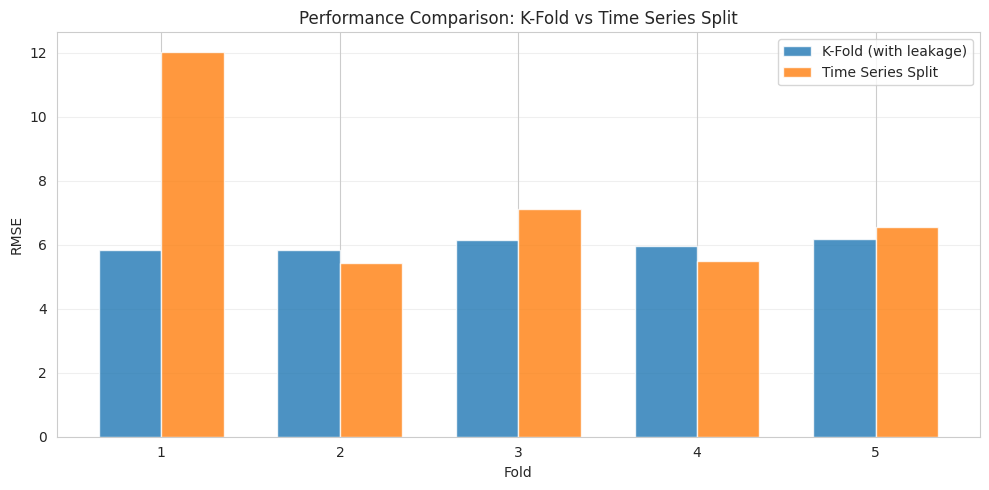

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(5) + 1
width = 0.35

bars1 = ax.bar(x - width/2, kfold_rmse, width, label='K-Fold (with leakage)', alpha=0.8)
bars2 = ax.bar(x + width/2, tscv_rmse, width, label='Time Series Split', alpha=0.8)

ax.set_xlabel('Fold')
ax.set_ylabel('RMSE')
ax.set_title('Performance Comparison: K-Fold vs Time Series Split')
ax.set_xticks(x)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

**Critical Insight**: Using K-fold on time series gives misleadingly good performance because the model can "peek" at future data.

### Understanding Forward Chaining

Time series split uses an expanding training window. Let's examine the fold sizes.

In [22]:
tscv = TimeSeriesSplit(n_splits=5)

print("Time Series Split - Fold Information:")
print("=" * 60)
train_sizes = []
test_sizes = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_ts), 1):
    train_sizes.append(len(train_idx))
    test_sizes.append(len(test_idx))
    print(f"Fold {fold}:")
    print(f"  Train: samples {train_idx[0]:3d} to {train_idx[-1]:3d} (n={len(train_idx):3d})")
    print(f"  Test:  samples {test_idx[0]:3d} to {test_idx[-1]:3d} (n={len(test_idx):3d})")

Time Series Split - Fold Information:
Fold 1:
  Train: samples   0 to  32 (n= 33)
  Test:  samples  33 to  65 (n= 33)
Fold 2:
  Train: samples   0 to  65 (n= 66)
  Test:  samples  66 to  98 (n= 33)
Fold 3:
  Train: samples   0 to  98 (n= 99)
  Test:  samples  99 to 131 (n= 33)
Fold 4:
  Train: samples   0 to 131 (n=132)
  Test:  samples 132 to 164 (n= 33)
Fold 5:
  Train: samples   0 to 164 (n=165)
  Test:  samples 165 to 197 (n= 33)


Visualize the expanding window.

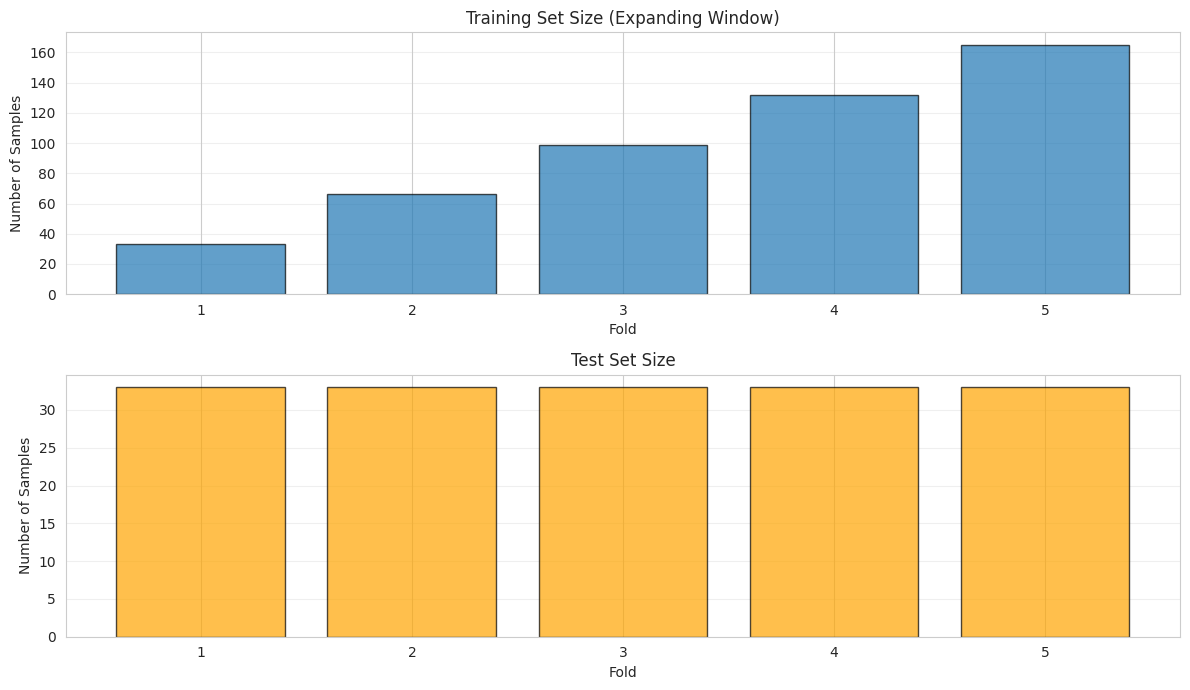

In [23]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7))

folds = np.arange(1, 6)

# Training set sizes
ax1.bar(folds, train_sizes, alpha=0.7, edgecolor='black')
ax1.set_xlabel('Fold')
ax1.set_ylabel('Number of Samples')
ax1.set_title('Training Set Size (Expanding Window)')
ax1.grid(True, alpha=0.3, axis='y')

# Test set sizes
ax2.bar(folds, test_sizes, alpha=0.7, edgecolor='black', color='orange')
ax2.set_xlabel('Fold')
ax2.set_ylabel('Number of Samples')
ax2.set_title('Test Set Size')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

**Pattern**: Training set grows with each fold (expanding window), while test set size remains constant.

### Practical Example: Sales Forecasting

Let's apply time series CV to a realistic scenario with seasonal sales data.

In [24]:
# Create more realistic sales data with weekly seasonality
n_weeks = 104  # 2 years of weekly data
weeks = np.arange(n_weeks)

# Growth trend
trend = 1000 + 5 * weeks

# Annual seasonality (strong in Q4)
annual = 200 * np.sin(2 * np.pi * weeks / 52 - np.pi/2)

# Weekly seasonality (weekend effect)
weekly = 50 * np.sin(2 * np.pi * weeks / 4)

# Random noise
np.random.seed(42)
noise = np.random.randn(n_weeks) * 50

sales = trend + annual + weekly + noise

# Create features
X_sales = np.column_stack([
    weeks,
    np.sin(2 * np.pi * weeks / 52),  # annual cycle
    np.cos(2 * np.pi * weeks / 52),
    np.sin(2 * np.pi * weeks / 4),   # weekly cycle
    np.cos(2 * np.pi * weeks / 4),
])
y_sales = sales

print(f"Sales data shape: {X_sales.shape}")
print(f"Sales range: ${y_sales.min():.0f} to ${y_sales.max():.0f}")

Sales data shape: (104, 5)
Sales range: $825 to $1661


Visualize the sales data.

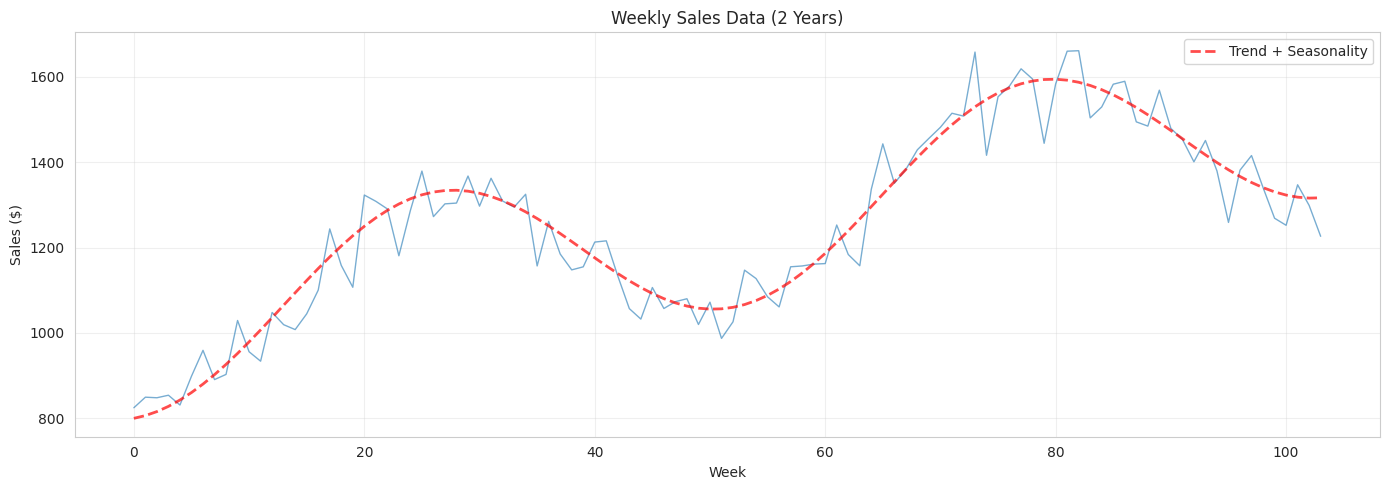

In [25]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(weeks, y_sales, alpha=0.6, linewidth=1)
ax.plot(weeks, trend + annual, 'r--', alpha=0.7, linewidth=2, label='Trend + Seasonality')
ax.set_xlabel('Week')
ax.set_ylabel('Sales ($)')
ax.set_title('Weekly Sales Data (2 Years)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Evaluate forecasting performance using time series CV.

In [26]:
model = Ridge(alpha=10.0)
tscv = TimeSeriesSplit(n_splits=5)

fold_results = []
for fold, (train_idx, test_idx) in enumerate(tscv.split(X_sales), 1):
    # Train and predict
    model.fit(X_sales[train_idx], y_sales[train_idx])
    y_pred = model.predict(X_sales[test_idx])
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_sales[test_idx], y_pred))
    mae = np.mean(np.abs(y_sales[test_idx] - y_pred))
    
    fold_results.append({
        'fold': fold,
        'train_weeks': (weeks[train_idx[0]], weeks[train_idx[-1]]),
        'test_weeks': (weeks[test_idx[0]], weeks[test_idx[-1]]),
        'rmse': rmse,
        'mae': mae
    })
    
    print(f"Fold {fold}: Train weeks {weeks[train_idx[0]]}-{weeks[train_idx[-1]]}, "
          f"Test weeks {weeks[test_idx[0]]}-{weeks[test_idx[-1]]}")
    print(f"         RMSE=${rmse:.2f}, MAE=${mae:.2f}")

avg_rmse = np.mean([r['rmse'] for r in fold_results])
avg_mae = np.mean([r['mae'] for r in fold_results])
print(f"\nAverage RMSE: ${avg_rmse:.2f}")
print(f"Average MAE:  ${avg_mae:.2f}")

Fold 1: Train weeks 0-18, Test weeks 19-35
         RMSE=$102.54, MAE=$75.35
Fold 2: Train weeks 0-35, Test weeks 36-52
         RMSE=$376.52, MAE=$354.43
Fold 3: Train weeks 0-52, Test weeks 53-69
         RMSE=$66.87, MAE=$53.32
Fold 4: Train weeks 0-69, Test weeks 70-86
         RMSE=$89.12, MAE=$80.68
Fold 5: Train weeks 0-86, Test weeks 87-103
         RMSE=$71.82, MAE=$58.43

Average RMSE: $141.37
Average MAE:  $124.44


Visualize predictions vs actuals for each fold.

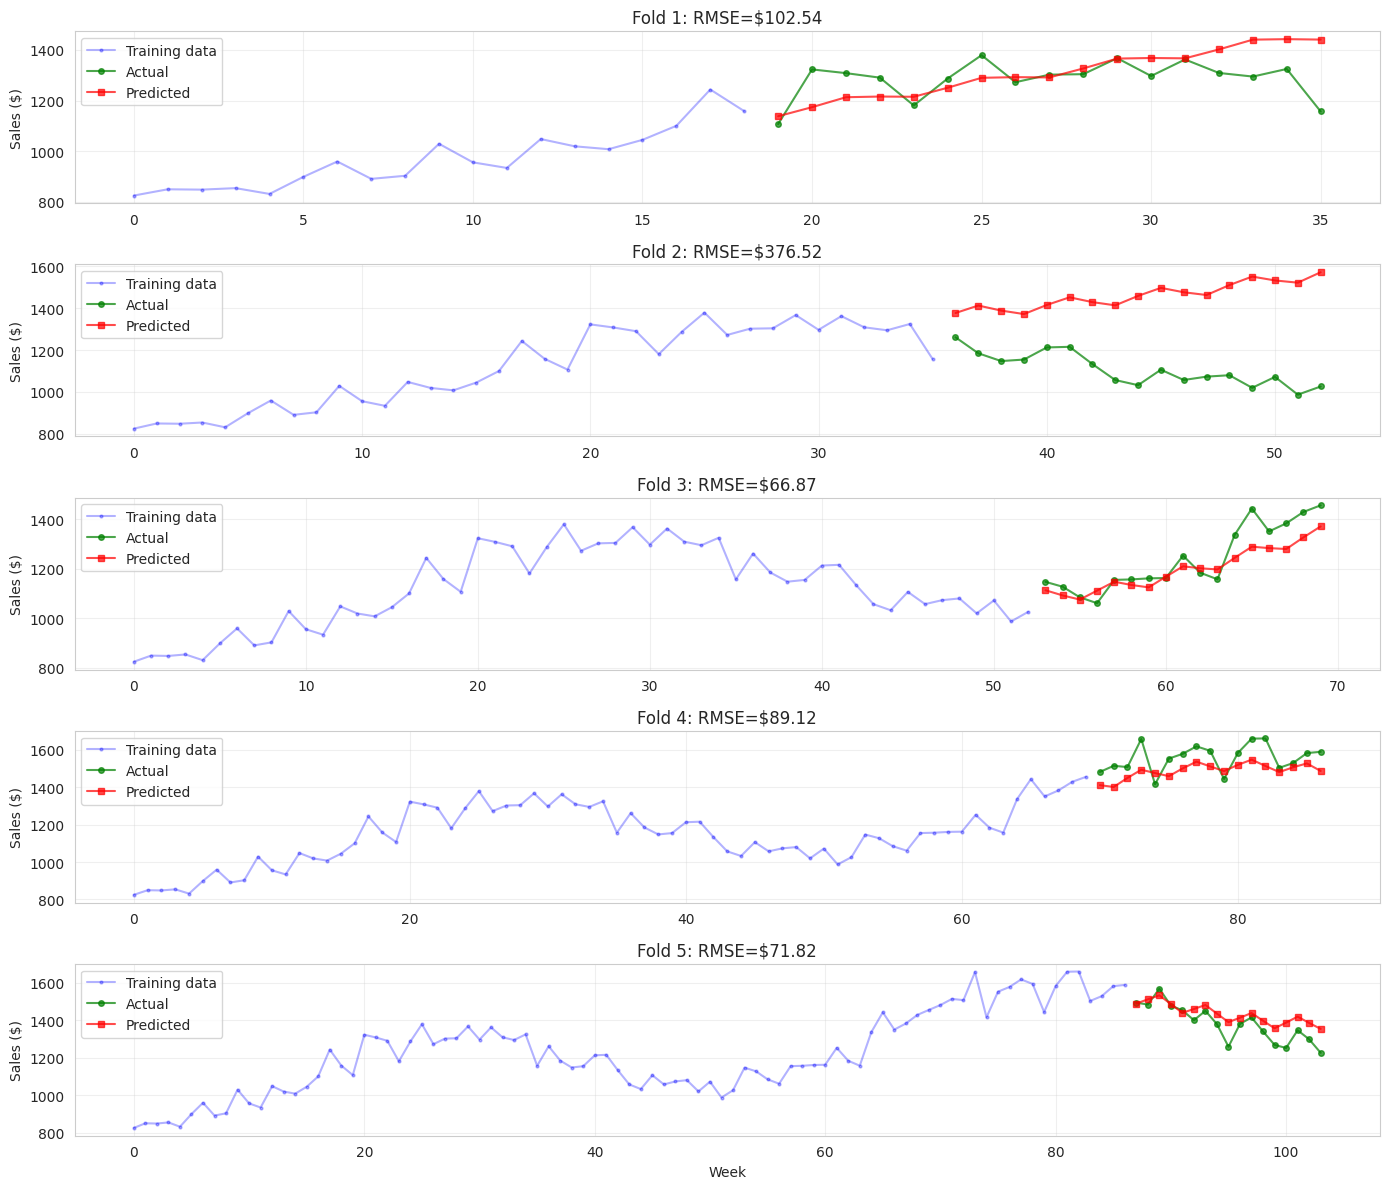

In [27]:
fig, axes = plt.subplots(5, 1, figsize=(14, 12))

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_sales)):
    # Train and predict
    model.fit(X_sales[train_idx], y_sales[train_idx])
    y_pred = model.predict(X_sales[test_idx])
    
    ax = axes[fold]
    
    # Plot training data
    ax.plot(weeks[train_idx], y_sales[train_idx], 'o-', alpha=0.3, 
            markersize=2, label='Training data', color='blue')
    
    # Plot test data
    ax.plot(weeks[test_idx], y_sales[test_idx], 'o-', alpha=0.7,
            markersize=4, label='Actual', color='green')
    
    # Plot predictions
    ax.plot(weeks[test_idx], y_pred, 's-', alpha=0.7,
            markersize=4, label='Predicted', color='red')
    
    ax.set_ylabel('Sales ($)')
    ax.set_title(f'Fold {fold+1}: RMSE=${fold_results[fold]["rmse"]:.2f}')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    
    if fold == 4:
        ax.set_xlabel('Week')

plt.tight_layout()
plt.show()

**Observation**: Each fold tests on data from later time periods, simulating real-world forecasting where we predict the future.

## Summary and Best Practices

We've explored three essential cross-validation techniques. Here's when to use each:

### Decision Guide

**Use K-Fold CV when:**
- Data is i.i.d. (independent and identically distributed)
- Classes are roughly balanced in classification
- No temporal ordering exists
- Common choice: K=5 or K=10

**Use Stratified K-Fold CV when:**
- Classification tasks (almost always)
- Imbalanced class distributions
- Want to preserve class proportions across folds
- Should be the default for classification

**Use Time Series Split when:**
- Data has temporal ordering
- Past observations predict future values
- Testing must simulate real-world deployment
- Data leakage would invalidate results

### Quick Reference Table

Create a visual comparison of the three methods.

In [28]:
import pandas as pd

comparison = pd.DataFrame({
    'Method': ['K-Fold', 'Stratified K-Fold', 'Time Series Split'],
    'Data Type': ['General', 'Classification', 'Time Series'],
    'Shuffling': ['Yes (optional)', 'Yes (optional)', 'No (never)'],
    'Class Balance': ['Not preserved', 'Preserved', 'N/A'],
    'Temporal Order': ['Ignored', 'Ignored', 'Respected'],
    'Training Size': ['Constant', 'Constant', 'Expanding'],
    'Best For': ['Regression, balanced classes', 'Classification, imbalanced', 'Forecasting, sequences']
})

print(comparison.to_string(index=False))

           Method      Data Type      Shuffling Class Balance Temporal Order Training Size                     Best For
           K-Fold        General Yes (optional) Not preserved        Ignored      Constant Regression, balanced classes
Stratified K-Fold Classification Yes (optional)     Preserved        Ignored      Constant   Classification, imbalanced
Time Series Split    Time Series     No (never)           N/A      Respected     Expanding       Forecasting, sequences


### Common Pitfalls

**1. Using K-fold on time series data** → Always use TimeSeriesSplit

**2. Not stratifying for imbalanced classes** → Use StratifiedKFold

**3. Choosing K too large** → Increases variance and computation time

**4. Choosing K too small** → Increases bias in estimates

**5. Data leakage from preprocessing** → Apply preprocessing within each fold

### Key Takeaways

1. **Cross-validation provides more reliable estimates** than a single train/test split by using multiple folds

2. **Stratification is crucial for classification**, especially with imbalanced datasets

3. **Time series requires special handling** - never shuffle, always respect temporal order

4. **The choice of K involves a bias-variance trade-off** - K=5 or K=10 are good defaults

5. **Cross-validation helps detect overfitting** and provides confidence intervals for model performance